## Libraries

In [35]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np



Call some veriable from data cleaning process.

In [36]:
%store -r data
data=data

%store -r numerical_cols
numerical_cols=numerical_cols

%store -r categorical_cols
categorical_cols= categorical_cols




In [37]:
# Exclude the target column from features
target = 'Sale price'
if target in numerical_cols:
    numerical_cols.remove(target)
if target in categorical_cols:
    categorical_cols.remove(target)

### **Handle Outlier**

In this step, we will check for outliers for features. Since our evaluation metric is RMSE, which is sensitive to large erros, outliers can significantly measurement.

##### **Outlier Detection**

An outlier is a value that is significantly different from the rest of the data.
It may occur due to:

- measurement or entry errors,
- exceptional events,
- highly skewed distributions.

###### ** How to detect outlier?**

Most common method: IQR (Interquartile Range)
For a numerical variable X:

- Compute **Q1** = 25th percentile
- Compute **Q3** = 75th percentile
- Compute **IQR = Q3 – Q1**
- Compute the outlier boundaries:
    - Lower bound = Q1 − 1.5 × IQR
    - Upper bound = Q3 + 1.5 × IQR

Any value outside this interval is an outlier.

Let's see the box plot to see status of data

### Umgang mit Ausreißern 
Ausreißer sind anormale Werte, die sich deutlich vom Rest der Datenpunkte unterscheiden. Wenn du zum Beispiel einen Gehaltsdatensatz hast, bei dem die meisten Beobachtungen zwischen 90 und 120 Tausend Dollar liegen, ist eine Gehaltszahl wie 400 Tausend Dollar oder 10 Tausend Dollar ein Ausreißer

In [38]:
def detect_all_outliers(cols):
    results = {}

    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)][col]

        results[col] = {
            "outliers": outliers.tolist(),
            "count": len(outliers),
            "lower_bound": lower,
            "upper_bound": upper
        }
    return results


In [39]:
detect_all_outliers(numerical_cols)


{'year of manufacture': {'outliers': [2022.0,
   2024.0,
   2018.0,
   2019.0,
   2022.0,
   2019.0,
   2018.0,
   2019.0],
  'count': 8,
  'lower_bound': 2019.25,
  'upper_bound': 2021.25},
 'Engine power (kilowatt)': {'outliers': [],
  'count': 0,
  'lower_bound': 70.75,
  'upper_bound': 116.75},
 'Engine power (Horsepower)': {'outliers': [],
  'count': 0,
  'lower_bound': 120.0,
  'upper_bound': 120.0},
 'Cubic capacity': {'outliers': [],
  'count': 0,
  'lower_bound': 1122.5,
  'upper_bound': 2126.5},
 ' Number of gears': {'outliers': [1, 1, 8, 1, 1],
  'count': 5,
  'lower_bound': 3.5,
  'upper_bound': 7.5},
 'CO2 (g/km)': {'outliers': [],
  'count': 0,
  'lower_bound': -213.0,
  'upper_bound': 355.0},
 'Tank capacity': {'outliers': [],
  'count': 0,
  'lower_bound': 27.5,
  'upper_bound': 95.5},
 'Mileage': {'outliers': [],
  'count': 0,
  'lower_bound': -91225.5,
  'upper_bound': 307454.5},
 'Empty weight (kg)': {'outliers': [],
  'count': 0,
  'lower_bound': 1269.25,
  'upper_b

In [40]:
import numpy as np

# Baujahr
data.loc[data["year of manufacture"] > 2024, "year of manufacture"] = np.nan

# Kubik
data.loc[data["Cubic capacity"] == 0, "Cubic capacity"] = np.nan

# Höchstgeschwindigkeit
data.loc[data["max_speed_kmh"] == 0, "max_speed_kmh"] = np.nan

# Beschleunigung (realistisch < 30 Sekunden)
data.loc[data["Acceleration (0-100Km/h)"] > 30, "Acceleration (0-100Km/h)"] = np.nan

# Median-Imputation
cols_fix = [
    "year of manufacture",
    "Cubic capacity",
    "max_speed_kmh",
    "Acceleration (0-100Km/h)"
]

data[cols_fix] = data[cols_fix].fillna(data[cols_fix].median())


In [41]:
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
    return df


cols_to_cap = [
    "Engine power (kilowatt)",
    "Engine power (Horsepower)",
    "Tank capacity",
    "Empty weight (kg)",
    "Permitted gross weight"
]

data = cap_outliers_iqr(data, cols_to_cap)


In [42]:
acc=data["Acceleration (0-100Km/h)"]
print(acc.head(30))

0      9.50
1      4.75
2      4.75
3      4.75
4      4.75
5      9.50
6      4.75
7      4.75
8      4.75
9      4.75
10     0.00
11     4.75
12     4.75
13     0.00
14     4.75
15     4.75
16     4.75
17    10.30
18     4.75
19     9.50
20     4.75
21     4.75
22     4.75
23     0.00
24     4.75
25     4.75
26     0.00
Name: Acceleration (0-100Km/h), dtype: float64


In [43]:
year=data[cols_fix]
print(data.head(30))

     Brand                   Model  year of manufacture  \
0   Hyundai  Nexo Fuel Cell Sports               2022.0   
1   Renault      Grand Scenic BLUE               2020.0   
2   Hyundai  Nexo Fuel Cell Sports               2024.0   
3      Ford             Ford Focus               2020.0   
4   Renault       Kango rapid Blue               2021.0   
5      Ford             Ford Focus               2020.0   
6   Renault      Grand Scenic BLUE               2020.0   
7   Renault      Grand Scenic BLUE               2020.0   
8   Renault      Grand Scenic BLUE               2018.0   
9   Renault      Grand Scenic BLUE               2020.0   
10  Renault       Kango rapid Blue               2020.0   
11  Renault      Grand Scenic BLUE               2020.0   
12  Hyundai                 loniq5               2021.0   
13  Renault       Kango rapid Blue               2021.0   
14  Renault      Grand Scenic BLUE               2020.0   
15  Renault       Kango rapid Blue               2020.0 

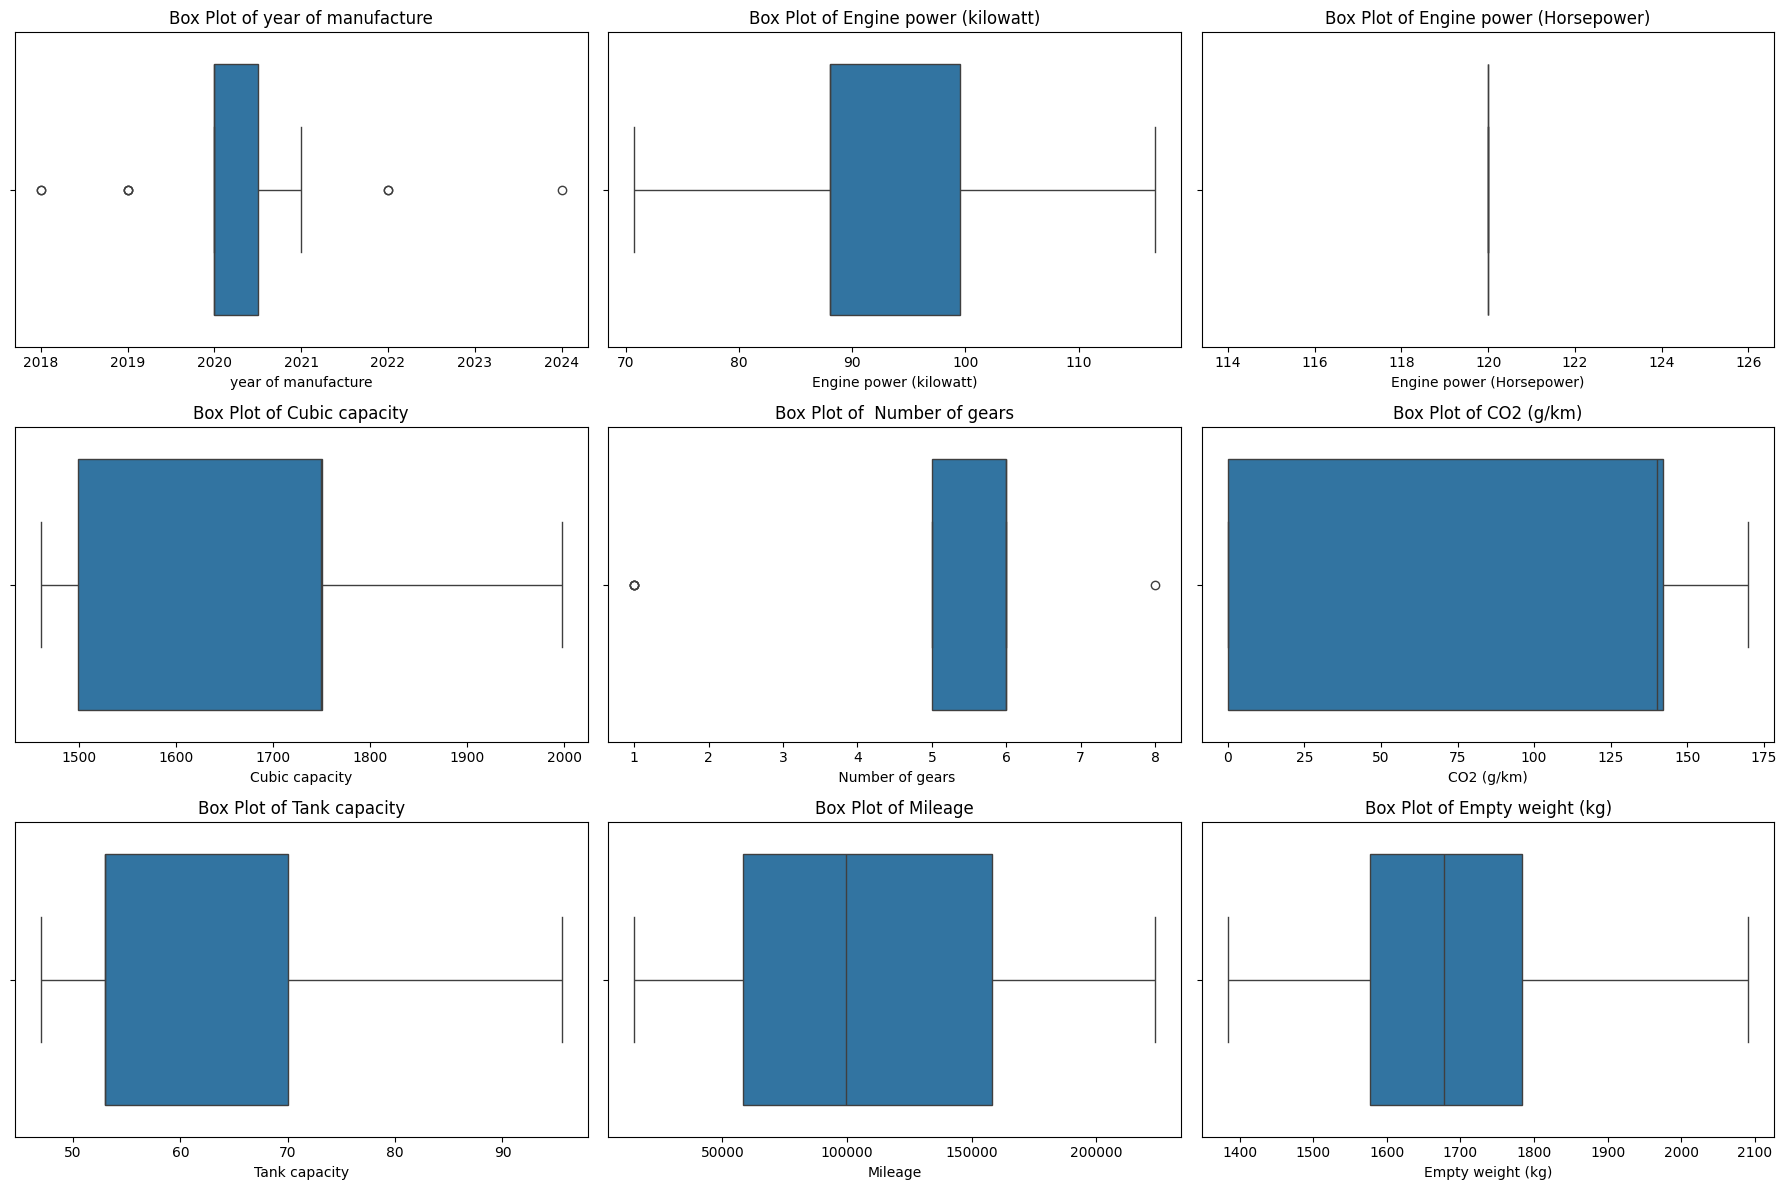

In [44]:
def box_plot(cols):
    import math
    n = len(cols)

    # Determine grid size automatically (3 columns per row)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(x=data[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')

    # Hide unused axes if columns don't fill the grid
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
box_plot(numerical_cols[:9])

#### **Categorical Encoding**
##### **Mean-Target Encoding**

For Mean Target_Encoding we will take variable  with many unique variable.
- Calculate the Mean Target (Price) for each category
- Replace category in with its corresponding Mean Price

#### **OneHotEnconding, CategoricalEncoding**

In [45]:

# 4. Preprocessor
# -------------------------------
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categoricals_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numerical_cols),
    
    ('categorie', categoricals_pipeline, categorical_cols)
])


#### **Apply Preprocessor to Data**

In [46]:
# Fit and transform to trainning data
X_processed = preprocessor.fit_transform(data)

# should be <class 'numpy.ndarray'>
print(type(X_processed))  

# number of rows × number of features after encoding
print(X_processed.shape)  


<class 'numpy.ndarray'>
(27, 155)


In [47]:

X_processed_data = pd.DataFrame(X_processed)
#print(X_processed_data.head())

In [48]:
# Check the data type of the array
print(X_processed.dtype)  

# Or check if any element is of object type
if np.issubdtype(X_processed.dtype, np.object_):
    print("X_processed contains object types!")
else:
    print("X_processed is fully numeric.")

float64
X_processed is fully numeric.


#### **CHECKPOINT**

In [49]:
%store preprocessor


Stored 'preprocessor' (ColumnTransformer)
